In [1]:
# 1. Import libraries, configure plotting, and set global options.
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from catboost import CatBoostRegressor
from IPython.display import display
from sklearn.base import clone
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.linear_model import ElasticNet, Lasso
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import KFold
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from xgboost import XGBRegressor

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 200)
pd.set_option("display.max_rows", 200)
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["axes.titlesize"] = 13
plt.rcParams["axes.labelsize"] = 11

RANDOM_STATE = 42
print("Libraries and plotting configuration are ready.")
        


Libraries and plotting configuration are ready.


In [2]:
# 2. Load the raw competition data and keep untouched copies for EDA.
train_raw = pd.read_csv("train.csv")
test_raw = pd.read_csv("test.csv")
test_id = test_raw["Id"].copy()

print(f"Train shape: {train_raw.shape}")
print(f"Test shape : {test_raw.shape}")
display(train_raw.head())
        


Train shape: (1460, 81)
Test shape : (1459, 80)


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2003,2003,Gable,CompShg,VinylSd,VinylSd,BrkFace,196.0,Gd,TA,PConc,Gd,TA,No,GLQ,706,Unf,0,150,856,GasA,Ex,Y,SBrkr,856,854,0,1710,1,0,2,1,3,1,Gd,8,Typ,0,NaN,Attchd,2003.0,RFn,2,548,TA,TA,Y,0,61,0,0,0,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,FR2,Gtl,Veenker,Feedr,Norm,1Fam,1Story,6,8,1976,1976,Gable,CompShg,MetalSd,MetalSd,NaN,0.0,TA,TA,CBlock,Gd,TA,Gd,ALQ,978,Unf,0,284,1262,GasA,Ex,Y,SBrkr,1262,0,0,1262,0,1,2,0,3,1,TA,6,Typ,1,TA,Attchd,1976.0,RFn,2,460,TA,TA,Y,298,0,0,0,0,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2001,2002,Gable,CompShg,VinylSd,VinylSd,BrkFace,162.0,Gd,TA,PConc,Gd,TA,Mn,GLQ,486,Unf,0,434,920,GasA,Ex,Y,SBrkr,920,866,0,1786,1,0,2,1,3,1,Gd,6,Typ,1,TA,Attchd,2001.0,RFn,2,608,TA,TA,Y,0,42,0,0,0,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,Crawfor,Norm,Norm,1Fam,2Story,7,5,1915,1970,Gable,CompShg,Wd Sdng,Wd Shng,NaN,0.0,TA,TA,BrkTil,TA,Gd,No,ALQ,216,Unf,0,540,756,GasA,Gd,Y,SBrkr,961,756,0,1717,1,0,1,0,3,1,Gd,7,Typ,1,Gd,Detchd,1998.0,Unf,3,642,TA,TA,Y,0,35,272,0,0,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,FR2,Gtl,NoRidge,Norm,Norm,1Fam,2Story,8,5,2000,2000,Gable,CompShg,VinylSd,VinylSd,BrkFace,350.0,Gd,TA,PConc,Gd,TA,Av,GLQ,655,Unf,0,490,1145,GasA,Ex,Y,SBrkr,1145,1053,0,2198,1,0,2,1,4,1,Gd,9,Typ,1,TA,Attchd,2000.0,RFn,3,836,TA,TA,Y,192,84,0,0,0,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [3]:
# 3. Build a compact structural summary so the notebook is easy to audit on Kaggle and GitHub.
summary = pd.DataFrame({
    "dtype": train_raw.dtypes.astype(str),
    "missing_train": train_raw.isnull().sum(),
    "missing_pct_train": (train_raw.isnull().mean() * 100).round(2),
    "unique_train": train_raw.nunique(),
})

print("Target summary:")
display(train_raw["SalePrice"].describe().to_frame(name="SalePrice"))
print()
print("Feature summary:")
display(summary.head(20))
        


Target summary:


,SalePrice
count,1460.000000
mean,180921.195890
std,79442.502883
min,34900.000000
25%,129975.000000
50%,163000.000000
75%,214000.000000
max,755000.000000



Feature summary:


,dtype,missing_train,missing_pct_train,unique_train
Id,int64,0,0.00,1460
MSSubClass,int64,0,0.00,15
MSZoning,object,0,0.00,5
LotFrontage,float64,259,17.74,110
LotArea,int64,0,0.00,1073
Street,object,0,0.00,2
Alley,object,1369,93.77,2
LotShape,object,0,0.00,4
LandContour,object,0,0.00,4
Utilities,object,0,0.00,2


In [4]:
# 4. Inspect missing values and datatype balance before any preprocessing.
missing_table = (
    train_raw.isnull()
    .sum()
    .sort_values(ascending=False)
    .rename("missing_count")
    .to_frame()
)
missing_table["missing_pct"] = (missing_table["missing_count"] / len(train_raw) * 100).round(2)

dtype_balance = train_raw.dtypes.astype(str).value_counts().rename_axis("dtype").reset_index(name="count")

print("Top missing features:")
display(missing_table[missing_table["missing_count"] > 0].head(20))
print("Datatype balance:")
display(dtype_balance)
        


Top missing features:


,missing_count,missing_pct
PoolQC,1453,99.52
MiscFeature,1406,96.30
Alley,1369,93.77
Fence,1179,80.75
MasVnrType,872,59.73
FireplaceQu,690,47.26
LotFrontage,259,17.74
GarageQual,81,5.55
GarageFinish,81,5.55
GarageType,81,5.55


Datatype balance:


,dtype,count
0,object,43
1,int64,35
2,float64,3


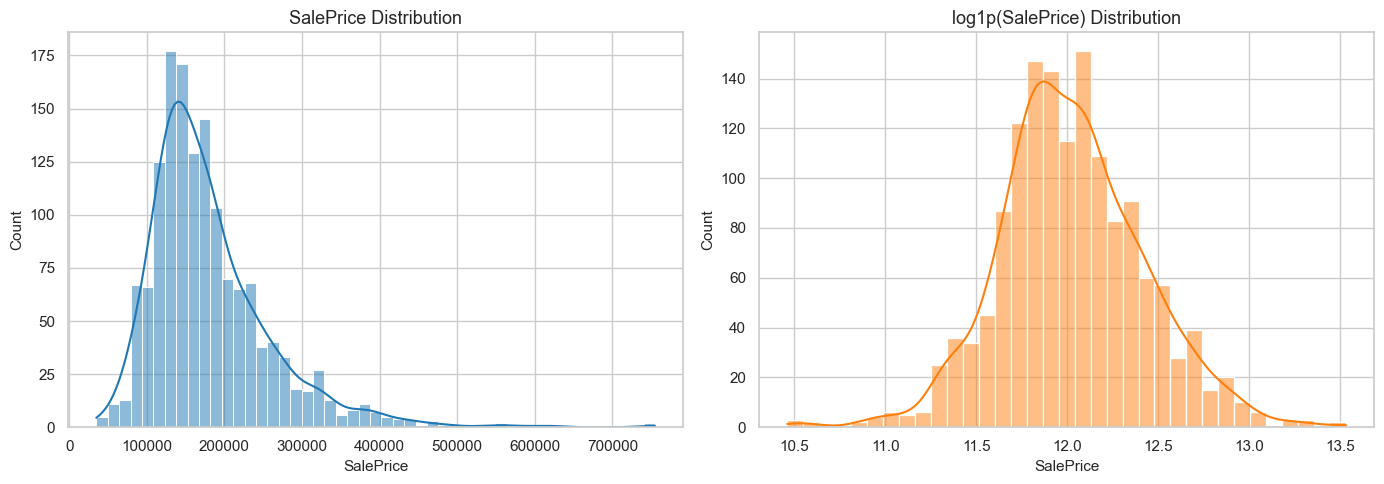

In [5]:
# 5. Visualize the target distribution before modeling.
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot the raw sale price distribution.
sns.histplot(train_raw["SalePrice"], kde=True, ax=axes[0], color="#1f77b4")
axes[0].set_title("SalePrice Distribution")

# Plot the log-transformed target distribution used by the competition metric.
sns.histplot(np.log1p(train_raw["SalePrice"]), kde=True, ax=axes[1], color="#ff7f0e")
axes[1].set_title("log1p(SalePrice) Distribution")

plt.tight_layout()
plt.show()
        


Top numeric correlations with SalePrice:


,corr_with_saleprice
SalePrice,1.000000
OverallQual,0.790982
GrLivArea,0.708624
GarageCars,0.640409
GarageArea,0.623431
TotalBsmtSF,0.613581
1stFlrSF,0.605852
FullBath,0.560664
TotRmsAbvGrd,0.533723
YearBuilt,0.522897


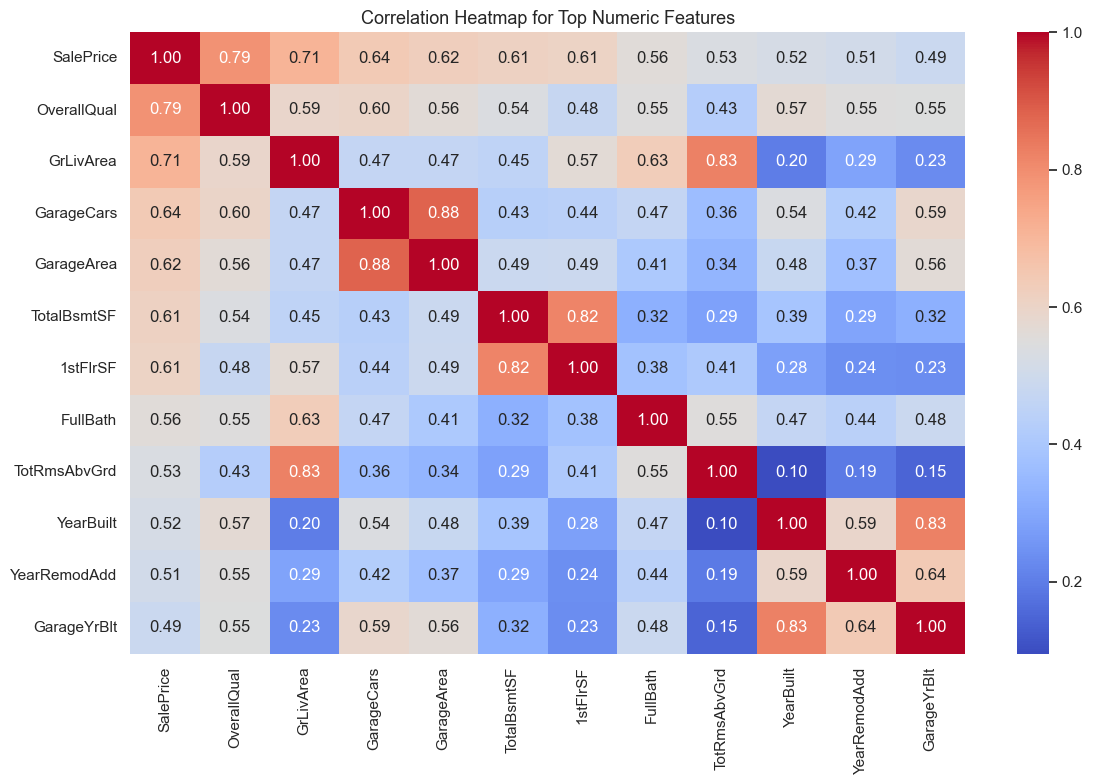

In [6]:
# 6. Explore the strongest numeric relationships with the target.
numeric_corr = train_raw.select_dtypes(include=[np.number]).corr(numeric_only=True)["SalePrice"].sort_values(ascending=False)
top_corr_features = numeric_corr.head(12).index.tolist()

print("Top numeric correlations with SalePrice:")
display(numeric_corr.head(15).to_frame(name="corr_with_saleprice"))

plt.figure(figsize=(12, 8))
sns.heatmap(train_raw[top_corr_features].corr(numeric_only=True), cmap="coolwarm", annot=True, fmt=".2f")
plt.title("Correlation Heatmap for Top Numeric Features")
plt.tight_layout()
plt.show()
        


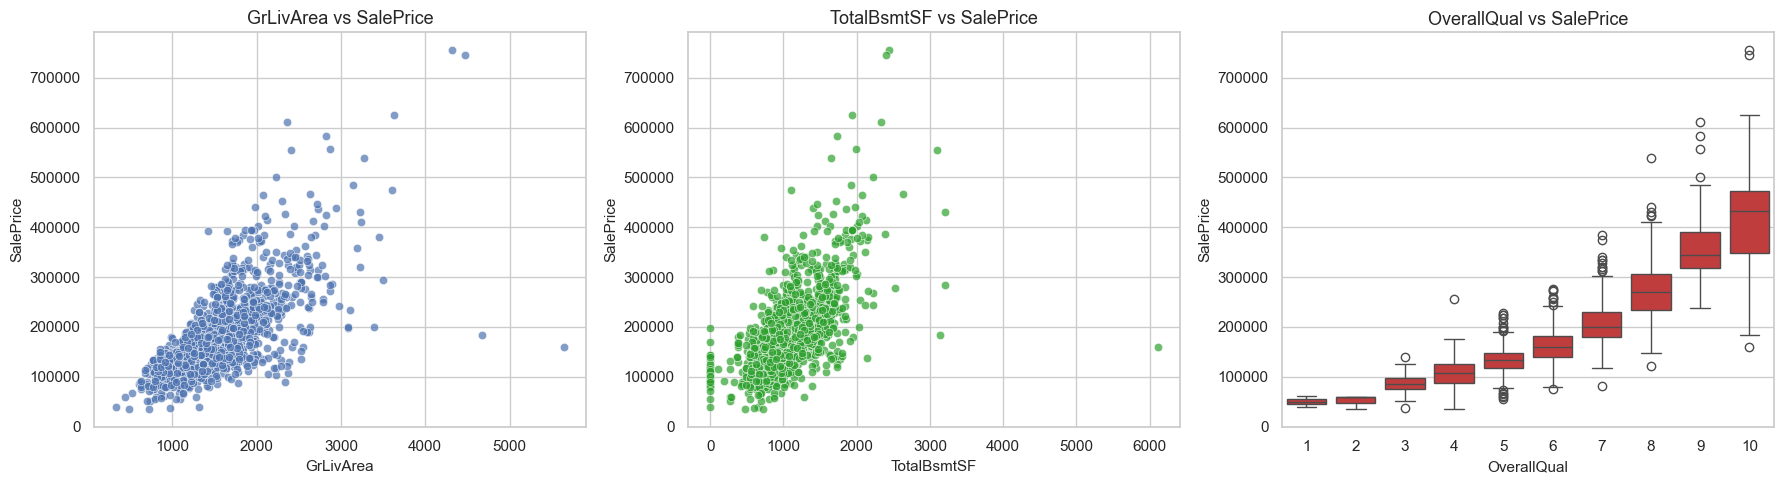

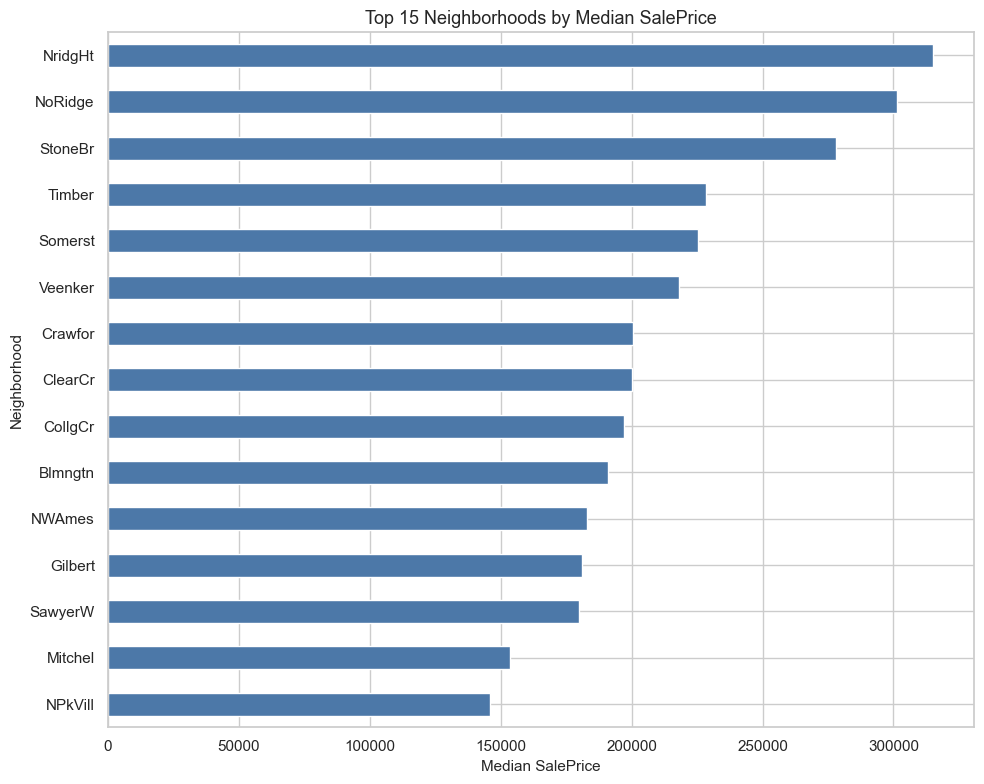

In [7]:
# 7. Explore high-signal feature interactions and neighborhood behavior.
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot living area against price to inspect large-home outliers.
sns.scatterplot(data=train_raw, x="GrLivArea", y="SalePrice", ax=axes[0], alpha=0.7)
axes[0].set_title("GrLivArea vs SalePrice")

# Plot basement size against price for another strong size signal.
sns.scatterplot(data=train_raw, x="TotalBsmtSF", y="SalePrice", ax=axes[1], alpha=0.7, color="#2ca02c")
axes[1].set_title("TotalBsmtSF vs SalePrice")

# Plot overall quality against price to confirm the ordinal quality trend.
sns.boxplot(data=train_raw, x="OverallQual", y="SalePrice", ax=axes[2], color="#d62728")
axes[2].set_title("OverallQual vs SalePrice")

plt.tight_layout()
plt.show()

neighborhood_rank = (
    train_raw.groupby("Neighborhood")["SalePrice"]
    .median()
    .sort_values(ascending=False)
    .head(15)
    .sort_values()
)

plt.figure(figsize=(10, 8))
neighborhood_rank.plot(kind="barh", color="#4c78a8")
plt.title("Top 15 Neighborhoods by Median SalePrice")
plt.xlabel("Median SalePrice")
plt.tight_layout()
plt.show()
        


In [8]:
# 8. Remove a few extreme outliers and create the combined modeling frame.
train = train_raw.copy()
test = test_raw.copy()

# Remove the classic large-area low-price outlier and a few broad size extremes.
train = train[~((train["GrLivArea"] > 4000) & (train["SalePrice"] < 300000))]
train = train[train["TotalBsmtSF"] < 3000]
train = train[train["LotArea"] < 100000]
train = train.reset_index(drop=True)

y_train = np.log1p(train["SalePrice"])
train_features = train.drop(columns=["SalePrice"])
n_train = len(train_features)
combined = pd.concat([train_features, test], axis=0, ignore_index=True)

print(f"Filtered train shape: {train_features.shape}")
print(f"Combined shape      : {combined.shape}")
        


Filtered train shape: (1451, 80)
Combined shape      : (2910, 80)


In [9]:
# 9. Apply explicit missing-value rules before feature engineering.
none_cols = [
    "Alley", "BsmtQual", "BsmtCond", "BsmtExposure", "BsmtFinType1", "BsmtFinType2",
    "FireplaceQu", "GarageType", "GarageFinish", "GarageQual", "GarageCond",
    "PoolQC", "Fence", "MiscFeature", "MasVnrType"
]
zero_cols = [
    "MasVnrArea", "BsmtFinSF1", "BsmtFinSF2", "BsmtUnfSF", "TotalBsmtSF",
    "BsmtFullBath", "BsmtHalfBath", "GarageYrBlt", "GarageArea", "GarageCars"
]
mode_cols = ["MSZoning", "Electrical", "KitchenQual", "Exterior1st", "Exterior2nd", "SaleType", "Utilities", "Functional"]

# Fill semantic "missing means absent" columns with the string None.
for col in none_cols:
    if col in combined.columns:
        combined[col] = combined[col].fillna("None")

# Fill area- or count-like columns with zero when missing means not present.
for col in zero_cols:
    if col in combined.columns:
        combined[col] = combined[col].fillna(0)

# Fill a few low-cardinality categorical columns with the most common value.
for col in mode_cols:
    if col in combined.columns:
        combined[col] = combined[col].fillna(combined[col].mode()[0])

# Fill LotFrontage within neighborhood first, then globally as fallback.
if "LotFrontage" in combined.columns:
    combined["LotFrontage"] = combined.groupby("Neighborhood")["LotFrontage"].transform(lambda s: s.fillna(s.median()))
    combined["LotFrontage"] = combined["LotFrontage"].fillna(combined["LotFrontage"].median())

# Fill any remaining categorical and numeric gaps safely.
for col in combined.select_dtypes(include=["object"]).columns:
    combined[col] = combined[col].fillna("None")

for col in combined.select_dtypes(exclude=["object"]).columns:
    combined[col] = combined[col].fillna(combined[col].median())

print(f"Remaining missing values after base fill: {int(combined.isnull().sum().sum())}")
        


Remaining missing values after base fill: 0


In [10]:
# 10. Engineer high-signal features and ordinal quality encodings.
combined["MSSubClass"] = combined["MSSubClass"].astype(str)

qual_map = {"None": 0, "Po": 1, "Fa": 2, "TA": 3, "Gd": 4, "Ex": 5}
quality_cols = ["ExterQual", "ExterCond", "BsmtQual", "BsmtCond", "HeatingQC", "KitchenQual", "FireplaceQu", "GarageQual", "GarageCond", "PoolQC"]

# Convert several quality-like features into ordered numeric scales.
for col in quality_cols:
    combined[col] = combined[col].map(qual_map).fillna(0).astype(int)

combined["BsmtExposure"] = combined["BsmtExposure"].map({"None": 0, "No": 1, "Mn": 2, "Av": 3, "Gd": 4}).fillna(0).astype(int)
combined["BsmtFinType1"] = combined["BsmtFinType1"].map({"None": 0, "Unf": 1, "LwQ": 2, "Rec": 3, "BLQ": 4, "ALQ": 5, "GLQ": 6}).fillna(0).astype(int)
combined["BsmtFinType2"] = combined["BsmtFinType2"].map({"None": 0, "Unf": 1, "LwQ": 2, "Rec": 3, "BLQ": 4, "ALQ": 5, "GLQ": 6}).fillna(0).astype(int)
combined["GarageFinish"] = combined["GarageFinish"].map({"None": 0, "Unf": 1, "RFn": 2, "Fin": 3}).fillna(0).astype(int)
combined["Fence"] = combined["Fence"].map({"None": 0, "MnWw": 1, "GdWo": 2, "MnPrv": 3, "GdPrv": 4}).fillna(0).astype(int)
combined["Functional"] = combined["Functional"].map({"Sal": 1, "Sev": 2, "Maj2": 3, "Maj1": 4, "Mod": 5, "Min2": 6, "Min1": 7, "Typ": 8}).fillna(8).astype(int)
combined["LotShape"] = combined["LotShape"].map({"IR3": 1, "IR2": 2, "IR1": 3, "Reg": 4}).fillna(0).astype(int)
combined["LandSlope"] = combined["LandSlope"].map({"Sev": 1, "Mod": 2, "Gtl": 3}).fillna(0).astype(int)
combined["PavedDrive"] = combined["PavedDrive"].map({"N": 0, "P": 1, "Y": 2}).fillna(0).astype(int)
combined["Street"] = (combined["Street"] == "Pave").astype(int)
combined["CentralAir"] = (combined["CentralAir"] == "Y").astype(int)

# Create size, age, and room-count features.
combined["TotalSF"] = combined["TotalBsmtSF"] + combined["1stFlrSF"] + combined["2ndFlrSF"]
combined["TotalPorchSF"] = combined["OpenPorchSF"] + combined["EnclosedPorch"] + combined["3SsnPorch"] + combined["ScreenPorch"] + combined["WoodDeckSF"]
combined["HouseAge"] = combined["YrSold"] - combined["YearBuilt"]
combined["RemodAge"] = combined["YrSold"] - combined["YearRemodAdd"]
combined["GarageAge"] = combined["YrSold"] - combined["GarageYrBlt"]
combined["IsRemodeled"] = (combined["YearBuilt"] != combined["YearRemodAdd"]).astype(int)
combined["TotalBath"] = combined["FullBath"] + 0.5 * combined["HalfBath"] + combined["BsmtFullBath"] + 0.5 * combined["BsmtHalfBath"]
combined["TotalRooms"] = combined["TotRmsAbvGrd"] + combined["FullBath"] + combined["HalfBath"] + combined["BsmtFullBath"] + combined["BsmtHalfBath"]

# Create quality-based composite features and interactions.
combined["OverallScore"] = combined["OverallQual"] + combined["OverallCond"]
combined["ExterScore"] = combined["ExterQual"] + combined["ExterCond"]
combined["BsmtScore"] = combined["BsmtQual"] + combined["BsmtCond"] + combined["BsmtExposure"]
combined["GarageScore"] = combined["GarageQual"] + combined["GarageCond"] + combined["GarageFinish"]
combined["TotalQualScore"] = combined["OverallQual"] + combined["ExterQual"] + combined["BsmtQual"] + combined["KitchenQual"] + combined["HeatingQC"] + combined["GarageQual"] + combined["FireplaceQu"]
combined["Qual_TotalSF"] = combined["OverallQual"] * combined["TotalSF"]
combined["Qual_GrLivArea"] = combined["OverallQual"] * combined["GrLivArea"]
combined["Qual_TotalBsmt"] = combined["OverallQual"] * combined["TotalBsmtSF"]
combined["Qual_Garage"] = combined["OverallQual"] * combined["GarageArea"]
combined["Qual_LotArea"] = combined["OverallQual"] * combined["LotArea"]
combined["Qual_Age"] = combined["OverallQual"] * combined["HouseAge"]
combined["Exter_Area"] = combined["ExterQual"] * combined["GrLivArea"]
combined["Kitchen_Area"] = combined["KitchenQual"] * combined["GrLivArea"]
combined["GarageScore_Area"] = combined["GarageScore"] * combined["GarageArea"]
combined["BsmtScore_Area"] = combined["BsmtScore"] * combined["TotalBsmtSF"]

# Add a few nonlinear terms and binary indicators for major house components.
combined["GrLivArea_sq"] = combined["GrLivArea"] ** 2
combined["TotalSF_sq"] = combined["TotalSF"] ** 2
combined["OverallQual_sq"] = combined["OverallQual"] ** 2
combined["HasPool"] = (combined["PoolArea"] > 0).astype(int)
combined["HasGarage"] = (combined["GarageArea"] > 0).astype(int)
combined["HasBsmt"] = (combined["TotalBsmtSF"] > 0).astype(int)
combined["HasFireplace"] = (combined["Fireplaces"] > 0).astype(int)
combined["Has2ndFloor"] = (combined["2ndFlrSF"] > 0).astype(int)
combined["HasMasVnr"] = (combined["MasVnrArea"] > 0).astype(int)
combined["HasPorch"] = (combined["TotalPorchSF"] > 0).astype(int)

# Build the neighborhood target-encoding feature that will be updated fold-safely during CV.
neighborhood_labels = combined["Neighborhood"].copy()
train_temp = combined.iloc[:n_train].copy()
train_temp["target"] = y_train.values
neigh_means = train_temp.groupby("Neighborhood")["target"].mean()
combined["NeighborhoodScore"] = combined["Neighborhood"].map(neigh_means).fillna(y_train.mean())

print(f"Feature count before encoding: {combined.shape[1]}")
        


Feature count before encoding: 114


In [11]:
# 11. Apply skew correction and one-hot encoding to finalize the design matrix.
num_cols = combined.select_dtypes(include=[np.number]).columns.tolist()
skewed = combined[num_cols].apply(lambda s: s.skew()).sort_values(ascending=False)
high_skew = skewed[skewed.abs() > 0.75].index.tolist()

# Log-transform highly skewed nonnegative numeric features.
for col in high_skew:
    if (combined[col] >= 0).all():
        combined[col] = np.log1p(combined[col])

combined = pd.get_dummies(combined, drop_first=True)
X_train = combined.iloc[:n_train].copy()
X_test = combined.iloc[n_train:].copy()
neighborhood_train = neighborhood_labels.iloc[:n_train].reset_index(drop=True)

print(f"Log1p applied to {len(high_skew)} skewed features.")
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape : {X_test.shape}")
        


Log1p applied to 58 skewed features.
X_train shape: (1451, 250)
X_test shape : (1459, 250)


In [12]:
# 12. Define leak-free cross-validation utilities for NeighborhoodScore and missing-value alignment.
kfold = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

def make_fold_neighborhood_scores(train_neigh, val_neigh, y_fold):
    # Compute leave-one-out style neighborhood means on the training fold only.
    fold_df = pd.DataFrame({"Neighborhood": train_neigh.values, "target": y_fold.values})
    stats = fold_df.groupby("Neighborhood")["target"].agg(["sum", "count"])
    global_mean = y_fold.mean()

    train_scores = []
    for neigh, target in zip(train_neigh, y_fold.values):
        neigh_sum = stats.loc[neigh, "sum"]
        neigh_count = stats.loc[neigh, "count"]
        if neigh_count > 1:
            train_scores.append((neigh_sum - target) / (neigh_count - 1))
        else:
            train_scores.append(global_mean)

    train_scores = pd.Series(train_scores, index=train_neigh.index, dtype=float)
    val_scores = val_neigh.map(stats["sum"] / stats["count"]).fillna(global_mean)
    return train_scores, val_scores

def apply_fold_safe_neighborhood_score(X_tr, X_val, y_tr):
    # Replace the precomputed neighborhood score with fold-safe values.
    X_tr_fold = X_tr.copy()
    X_val_fold = X_val.copy()
    train_scores, val_scores = make_fold_neighborhood_scores(
        neighborhood_train.loc[X_tr.index],
        neighborhood_train.loc[X_val.index],
        y_tr,
    )
    X_tr_fold.loc[:, "NeighborhoodScore"] = train_scores.values
    X_val_fold.loc[:, "NeighborhoodScore"] = val_scores.values
    return X_tr_fold, X_val_fold

def fill_missing_from_train(X_tr, X_other=None):
    # Align missing-value filling to the training partition only.
    fill_values = X_tr.median().fillna(0)
    X_tr_filled = X_tr.fillna(fill_values).fillna(0)
    if X_other is None:
        return X_tr_filled
    X_other_filled = X_other.fillna(fill_values).fillna(0)
    return X_tr_filled, X_other_filled

def cv_rmse(model, X=X_train, y=y_train):
    # Evaluate models with the competition-aligned RMSE on log1p prices.
    scores = []
    for tr_idx, val_idx in kfold.split(X, y):
        X_tr = X.iloc[tr_idx]
        X_val = X.iloc[val_idx]
        y_tr = y.iloc[tr_idx]
        y_val = y.iloc[val_idx]

        X_tr, X_val = apply_fold_safe_neighborhood_score(X_tr, X_val, y_tr)
        X_tr, X_val = fill_missing_from_train(X_tr, X_val)

        fitted = clone(model)
        fitted.fit(X_tr, y_tr)
        preds = fitted.predict(X_val)
        scores.append(np.sqrt(mean_squared_error(y_val, preds)))
    return np.array(scores)

print("Leak-free CV helpers are ready.")
        


Leak-free CV helpers are ready.


In [13]:
# 13. Define the final publishing-ready model stack and fixed blend weights.
models = {
    "lasso": make_pipeline(
        StandardScaler(with_mean=False),
        Lasso(alpha=0.0005, random_state=RANDOM_STATE, max_iter=50000),
    ),
    "enet": make_pipeline(
        StandardScaler(with_mean=False),
        ElasticNet(alpha=0.00045, l1_ratio=0.95, random_state=RANDOM_STATE, max_iter=50000),
    ),
    "gbr": GradientBoostingRegressor(
        n_estimators=3500,
        learning_rate=0.018,
        max_depth=3,
        min_samples_split=10,
        min_samples_leaf=4,
        max_features="sqrt",
        subsample=0.8,
        loss="huber",
        alpha=0.9,
        random_state=RANDOM_STATE,
    ),
    "xgb": XGBRegressor(
        n_estimators=3000,
        learning_rate=0.02,
        max_depth=4,
        min_child_weight=3,
        subsample=0.7,
        colsample_bytree=0.7,
        reg_alpha=0.005,
        reg_lambda=1.5,
        random_state=RANDOM_STATE,
        n_jobs=-1,
        verbosity=0,
    ),
    "catboost": CatBoostRegressor(
        iterations=3000,
        learning_rate=0.02,
        depth=6,
        l2_leaf_reg=5,
        random_strength=0.5,
        bagging_temperature=0.3,
        border_count=128,
        random_seed=RANDOM_STATE,
        verbose=0,
        allow_writing_files=False,
    ),
}

blend_weights = {
    "lasso": 0.3266,
    "enet": 0.1064,
    "gbr": 0.3382,
    "xgb": 0.0311,
    "catboost": 0.1977,
}

print("Models and fixed final blend weights are ready.")
        


Models and fixed final blend weights are ready.


In [14]:
# 14. Show a clean cross-validation table for the final published notebook.
cv_rows = []
for name, model in models.items():
    scores = cv_rmse(model)
    cv_rows.append({
        "model": name,
        "rmse_mean": scores.mean(),
        "rmse_std": scores.std(),
    })

cv_table = pd.DataFrame(cv_rows).sort_values("rmse_mean").reset_index(drop=True)
display(cv_table)
        


,model,rmse_mean,rmse_std
0,gbr,0.112146,0.003215
1,catboost,0.114834,0.002788
2,lasso,0.115144,0.002733
3,enet,0.115527,0.002829
4,xgb,0.115929,0.002968


In [15]:
# 15. Train the final models on full data, create the blend, and save the submission file.
X_train_full, X_test_full = fill_missing_from_train(X_train, X_test)
trained_models = {}

# Fit each final model on the full training matrix.
for name, model in models.items():
    fitted = clone(model)
    fitted.fit(X_train_full, y_train)
    trained_models[name] = fitted
    print(f"{name} trained")

# Build the final weighted blend in log space and convert back to dollar prices.
pred_matrix = np.column_stack([trained_models[name].predict(X_test_full) for name in blend_weights])
weight_vector = np.array([blend_weights[name] for name in blend_weights])
final_log = pred_matrix @ weight_vector
final_preds = np.maximum(np.expm1(final_log), 0)

submission = pd.DataFrame({"Id": test_id, "SalePrice": final_preds})
submission.to_csv("submission.csv", index=False)

print()
print(f"Saved submission.csv with {len(submission)} rows.")
print(f"Prediction mean: {submission['SalePrice'].mean():.2f}")
display(submission.head(10))
        


lasso trained
enet trained


gbr trained


xgb trained


catboost trained

Saved submission.csv with 1459 rows.
Prediction mean: 177483.95


,Id,SalePrice
0,1461,123535.747491
1,1462,160813.014735
2,1463,186981.672031
3,1464,198436.557076
4,1465,192258.506205
5,1466,172129.607870
6,1467,176753.172012
7,1468,164982.957975
8,1469,185286.528475
9,1470,122047.828351
